# Window Size Optimization
Grid search over MERGE_WINDOW & SELECTION_WINDOW sizes, along with other window parameters.
Plots Hit Rate vs FP for each parameter sweep.

In [7]:
import json, os, time, itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque
from tqdm.notebook import tqdm

os.makedirs('plots', exist_ok=True)
SCRIPT_DIR = os.getcwd()
WORKER_DATA_DIR = 'worker_data'
GROUND_TRUTH_JSON = 'attack.json'
VIDEOS_TO_MONITOR = [f'attacked_{i}' for i in range(1, 42)]

In [8]:
# ── Defaults (untouched unless overridden) ──────────────────────────────────
DEF = dict(
    BOUNDARY_TOLERANCE=2.5, TOLERANCE_SEC=2.5, LOCKOUT_PERIOD=5.0,
    MERGE_WINDOW=10.0, SELECTION_WINDOW_SEC=30.0, SELECTION_OVERLAP=0.1, SELECTION_MIN_GAP=0.5,
    VISUAL_MAX_FRAMES=30, VISUAL_MIN_WARMUP=10, K_VISUAL_THRESHOLD=2.5,
    VISUAL_COOLDOWN=3.0, VISUAL_PERSIST_NEEDED=2, VISUAL_PERSIST_WINDOW=4,
    SCENE_CHANGE_RATIO=8.0, SCENE_CHANGE_TOLERANCE=0.5,
    IFRAME_SANDWICH_ENABLED=True, IFRAME_CONTEXT_WINDOW=5,
    IFRAME_STABILITY_RATIO=3.0, IFRAME_MIN_CONTEXT=3,
    MV_WINDOW=60, MV_MIN_WARMUP=30, K_MV_THRESHOLD=4.5,
    MV_COOLDOWN=5.0, MV_PERSIST_NEEDED=3, MV_PERSIST_WINDOW=5,
    GOP_SHORT_RATIO=0.25, MOTION_JERK_ENABLED=True,
    JERK_WINDOW=5, JERK_ACCEL_THRESHOLD=2.5,
    AUDIO_SAMPLE_RATE=44100, AUDIO_BUFFER_SEC=15.0,
    AUDIO_MICRO_WINDOW_SEC=0.5, K_AUDIO_RMS_THRESHOLD=3.0,
    AUDIO_NOISE_FLOOR=800.0, AUDIO_COOLDOWN=3.0, AUDIO_PERSIST_NEEDED=2,
    SILENCE_THRESHOLD_RATIO=0.05, SILENCE_MIN_DURATION=2.0, SILENCE_COOLDOWN=30.0,
    FLUX_SAMPLE_RATE=22050, FLUX_WINDOW_SEC=0.05, FLUX_BUFFER_SEC=10.0,
    K_FLUX_THRESHOLD=3.0, FLUX_COOLDOWN=3.0, FLUX_PERSIST_NEEDED=3,
    MIN_SIGNALS_TO_CONFIRM=1, REQUIRE_MULTIMODAL=False,
    AUDIO_UPGRADE_WINDOW=2.5, MIN_EVENT_GAP=0.5,
    W_CONFIDENCE=0.50, W_MAGNITUDE=0.05, W_ACCELERATION=0.15,
    W_EDGE_CHANGE=0.10, W_UNIFORMITY=0.05, W_PERSISTENCE=0.15,
)
VISUAL_MOTION_SIGNALS = {'Visual', 'Motion'}
AUDIO_SIGNALS = {'AudioRMS', 'Silence', 'SpectralFlux'}
ALL_SIGNALS = ['Visual', 'Motion', 'AudioRMS', 'Silence', 'SpectralFlux']
print('Defaults loaded.')

Defaults loaded.


In [9]:
# ── Core detection logic (parameterised) ────────────────────────────────────
def adaptive_zscore(value, buffer, k):
    arr = np.array(buffer, dtype=np.float64)
    if len(arr) < 2: return 0.0, False
    mu, sigma = np.mean(arr), np.std(arr)
    if sigma < 1e-9: return 0.0, False
    z = (value - mu) / sigma
    return z, abs(z) > k

def confidence_score(w):
    return 1.0 if w >= 3 else (0.65 if w == 2 else 0.30)

def compute_trigger_score(weight, feats, p):
    return float(np.clip(
        p['W_CONFIDENCE']*confidence_score(weight)
        + p['W_MAGNITUDE']*feats.get('magnitude',0.5)
        + p['W_ACCELERATION']*feats.get('acceleration',0.5)
        + p['W_EDGE_CHANGE']*feats.get('edge_change',0.5)
        + p['W_UNIFORMITY']*feats.get('uniformity',0.5)
        + p['W_PERSISTENCE']*feats.get('persistence',0.5), 0.0, 1.0))

def run_detection(packets, p):
    frames, audio_samples, flux_samples = [], [], []
    for pkt in packets:
        st, fps = pkt['chunk_start_time'], pkt['fps']
        for idx, frm in enumerate(pkt['frames']):
            frames.append((st + idx/fps, frm['type'], int(frm['size'])))
        for r in pkt['audio_rms']:
            if r['time'] >= st - 0.001: audio_samples.append((r['time'], r['rms']))
        for f in pkt['spectral_flux']:
            if f['time'] >= st - 0.001: flux_samples.append((f['time'], f['flux']))
    frames.sort(key=lambda x: x[0])
    audio_samples.sort(key=lambda x: x[0])
    flux_samples.sort(key=lambda x: x[0])

    # Visual + Motion
    v_size_buf = deque(maxlen=p['VISUAL_MAX_FRAMES'])
    v_spike_flags = deque(maxlen=p['VISUAL_PERSIST_WINDOW'])
    v_last_trig = -999.0; v_triggers = []; v_sizes_sandwich = []
    scene_trans_end = 0.0
    mv_pb_buf = deque(maxlen=p['MV_WINDOW'])
    mv_spike_flags = deque(maxlen=p['MV_PERSIST_WINDOW'])
    mv_last_trig = -999.0; mv_last_i_t = -999.0
    mv_gop = deque(maxlen=30); mv_triggers = []
    jerk_history = deque(maxlen=p['JERK_WINDOW'])

    for (t, ptype, size) in frames:
        is_i = (ptype == 'I')
        if is_i:
            v_sizes_sandwich.append((t, size))
            cur_idx = len(v_sizes_sandwich)-1
            if len(v_size_buf) >= 2:
                prev = list(v_size_buf)[-1]
                if prev > 0 and size/prev > p['SCENE_CHANGE_RATIO']:
                    scene_trans_end = t + p['SCENE_CHANGE_TOLERANCE']
            spike = False
            if t >= scene_trans_end and t > p['LOCKOUT_PERIOD'] and len(v_size_buf) >= p['VISUAL_MIN_WARMUP']:
                _, spike = adaptive_zscore(size, v_size_buf, p['K_VISUAL_THRESHOLD'])
            v_spike_flags.append(1 if spike else 0)
            if (t > p['LOCKOUT_PERIOD'] and len(v_spike_flags) == p['VISUAL_PERSIST_WINDOW']
                    and sum(v_spike_flags) >= p['VISUAL_PERSIST_NEEDED']
                    and (t - v_last_trig) > p['VISUAL_COOLDOWN']
                    and (t - v_last_trig) > p['MIN_EVENT_GAP']):
                v_triggers.append(t); v_last_trig = t; v_spike_flags.clear()
            v_size_buf.append(size)
            if mv_last_i_t > 0:
                interval = t - mv_last_i_t
                if len(mv_gop) >= 10:
                    mean_gop = np.mean(mv_gop)
                    if (t > p['LOCKOUT_PERIOD'] and mean_gop > 0
                            and interval < mean_gop*p['GOP_SHORT_RATIO']
                            and (t - mv_last_trig) > p['MV_COOLDOWN']):
                        mv_triggers.append(t); mv_last_trig = t
                mv_gop.append(interval)
            mv_last_i_t = t
        if ptype in ('P','B'):
            jerk_history.append(size); mv_pb_buf.append(size)
            spike = False
            if t > p['LOCKOUT_PERIOD'] and len(mv_pb_buf) >= p['MV_MIN_WARMUP']:
                _, spike = adaptive_zscore(size, mv_pb_buf, p['K_MV_THRESHOLD'])
            mv_spike_flags.append(1 if spike else 0)
            if (t > p['LOCKOUT_PERIOD'] and len(mv_spike_flags) == p['VISUAL_PERSIST_WINDOW']
                    and sum(mv_spike_flags) >= p['VISUAL_PERSIST_NEEDED']
                    and (t - v_last_trig) > p['VISUAL_COOLDOWN']
                    and (t - v_last_trig) > p['MIN_EVENT_GAP']):
                mv_triggers.append(t); mv_last_trig = t; mv_spike_flags.clear()

    mv_triggers.sort()
    deduped_mv, last_t = [], -999.0
    for t in mv_triggers:
        if t - last_t > p['MV_COOLDOWN']: deduped_mv.append(t); last_t = t

    # AudioRMS + Silence
    rms_buf = deque(maxlen=max(1, int(p['AUDIO_BUFFER_SEC']/p['AUDIO_MICRO_WINDOW_SEC'])))
    rms_consec = 0; rms_last_trig = -999.0; rms_triggers = []
    sil_in = False; sil_start = -999.0; sil_last_trig = -999.0; sil_triggers = []
    for (micro_t, micro_rms) in audio_samples:
        if micro_t > p['LOCKOUT_PERIOD'] and len(rms_buf) == rms_buf.maxlen:
            mu = float(np.mean(rms_buf)); sigma = float(np.std(rms_buf))
            is_spike = (micro_rms > p['AUDIO_NOISE_FLOOR'] and sigma > 0
                        and micro_rms > mu + p['K_AUDIO_RMS_THRESHOLD']*sigma)
            rms_consec = rms_consec+1 if is_spike else 0
            if (rms_consec >= p['AUDIO_PERSIST_NEEDED']
                    and (micro_t - rms_last_trig) > p['AUDIO_COOLDOWN']
                    and (micro_t - rms_last_trig) > p['MIN_EVENT_GAP']):
                rms_triggers.append(micro_t); rms_last_trig = micro_t; rms_consec = 0
            if mu > p['AUDIO_NOISE_FLOOR']:
                is_silent = micro_rms < mu*p['SILENCE_THRESHOLD_RATIO']
                if is_silent and not sil_in: sil_in, sil_start = True, micro_t
                elif not is_silent and sil_in:
                    sil_in = False
                    dur = micro_t - sil_start
                    if dur >= p['SILENCE_MIN_DURATION'] and (sil_start - sil_last_trig) > p['SILENCE_COOLDOWN']:
                        sil_triggers.append(sil_start); sil_last_trig = sil_start
        rms_buf.append(micro_rms)

    # SpectralFlux
    flux_buf = deque(maxlen=max(10, int(p['FLUX_BUFFER_SEC']/p['FLUX_WINDOW_SEC'])))
    flux_consec = 0; flux_last_trig = -999.0; flux_triggers = []
    for (flux_t, fv) in flux_samples:
        if flux_t > p['LOCKOUT_PERIOD'] and len(flux_buf) >= int(flux_buf.maxlen*0.3):
            _, spike = adaptive_zscore(fv, flux_buf, p['K_FLUX_THRESHOLD'])
            flux_consec = flux_consec+1 if spike else 0
            if (flux_consec >= p['FLUX_PERSIST_NEEDED']
                    and (flux_t - flux_last_trig) > p['FLUX_COOLDOWN']
                    and (flux_t - flux_last_trig) > p['MIN_EVENT_GAP']):
                flux_triggers.append(flux_t); flux_last_trig = flux_t; flux_consec = 0
        flux_buf.append(fv)

    return {'Visual': v_triggers, 'Motion': deduped_mv,
            'AudioRMS': rms_triggers, 'Silence': sil_triggers, 'SpectralFlux': flux_triggers}

print('Detection function defined.')

Detection function defined.


In [10]:
# ── Fusion + selection (parameterised) ──────────────────────────────────────
def fuse_all_signals(signal_dict, p):
    all_events = sorted([{'time':t,'signal':lbl} for lbl,ts in signal_dict.items() for t in ts], key=lambda x: x['time'])
    if not all_events: return []
    used = [False]*len(all_events); clusters = []
    for i, ev in enumerate(all_events):
        if used[i]: continue
        cluster = [ev]; used[i] = True
        for j in range(i+1, len(all_events)):
            if used[j]: continue
            if all_events[j]['time'] - cluster[0]['time'] > p['TOLERANCE_SEC']: break
            cluster.append(all_events[j]); used[j] = True
        clusters.append(cluster)
    merged = []
    for cluster in clusters:
        sigs = list({e['signal'] for e in cluster})
        vm_sigs = [s for s in sigs if s in VISUAL_MOTION_SIGNALS]
        if not vm_sigs: continue
        avg_t = round(float(np.mean([e['time'] for e in cluster])), 2)
        base_weight = len(set(vm_sigs))
        audio_present = {e['signal'] for e in cluster if e['signal'] in AUDIO_SIGNALS and abs(e['time']-avg_t) <= p['AUDIO_UPGRADE_WINDOW']}
        weight = base_weight + len(audio_present)
        all_sigs = sorted(set(vm_sigs)|audio_present)
        feats = {k:0.5 for k in ['magnitude','acceleration','edge_change','uniformity','persistence']}
        score = compute_trigger_score(weight, feats, p)
        merged.append((avg_t, '+'.join(all_sigs), len(all_sigs), min(weight,5), feats, score))
    return sorted(merged, key=lambda x: x[0])

def apply_window_merge(fused_events, p):
    if not fused_events: return []
    result, i = [], 0
    while i < len(fused_events):
        group, j = [], i
        while j < len(fused_events) and fused_events[j][0] <= fused_events[i][0]+p['MERGE_WINDOW']:
            group.append(fused_events[j]); j += 1
        if len(group) >= 2:
            all_lbl = set(s for e in group for s in e[1].split('+'))
            feats = {k:0.5 for k in ['magnitude','acceleration','edge_change','uniformity','persistence']}
            score = compute_trigger_score(3, feats, p)
            result.append((round(float(np.mean([e[0] for e in group])),2), '+'.join(sorted(all_lbl)), len(all_lbl), 3, feats, score))
        else: result.append(group[0])
        i = j
    return result

def select_strongest_per_window(event_dicts, p):
    if not event_dicts: return [], []
    window_sec = p['SELECTION_WINDOW_SEC']
    overlap    = p['SELECTION_OVERLAP']
    min_gap    = p['SELECTION_MIN_GAP']
    hop_sec    = window_sec*(1.0-overlap)
    total_time = max(e['time'] for e in event_dicts)+1.0
    n_windows  = max(1, int(np.ceil((total_time-window_sec)/hop_sec))+1)
    kept_set   = set()
    for w in range(n_windows):
        ws, we = w*hop_sec, w*hop_sec+window_sec
        in_win = [i for i,e in enumerate(event_dicts) if ws <= e['time'] < we]
        if in_win: kept_set.add(max(in_win, key=lambda i: event_dicts[i]['score']))
    sorted_kept = sorted(kept_set, key=lambda i: event_dicts[i]['time'])
    final_kept, last_t = [], -999.0
    for i in sorted_kept:
        t = event_dicts[i]['time']
        if t-last_t >= min_gap: final_kept.append(i); last_t = t
    return [event_dicts[i] for i in range(len(event_dicts)) if i in kept_set], \
           [event_dicts[i] for i in range(len(event_dicts)) if i not in kept_set]

def validate_video(segments, final_events, p):
    segs = [dict(s, hit=None) for s in segments]
    fp_events = []
    for ev in final_events:
        ts, label, n_sig, weight, feats, score = ev
        claimed = False
        for seg in segs:
            ns = abs(ts-seg['start']) <= p['BOUNDARY_TOLERANCE']
            ne = abs(ts-seg['end'])   <= p['BOUNDARY_TOLERANCE']
            inside = seg['start'] < ts < seg['end']
            if (ns or ne or inside) and seg['hit'] is None:
                seg['hit'] = {'ts':ts,'label':label}; claimed = True; break
        if not claimed: fp_events.append({'ts':ts,'label':label})
    return segs, fp_events

def evaluate_one_video(video_id, gt_entry, p):
    json_path = os.path.join(SCRIPT_DIR, WORKER_DATA_DIR, f'{video_id}_worker_data.json')
    if not os.path.exists(json_path): return None
    with open(json_path) as f: data = json.load(f)
    packets = data['chunks']
    signal_dict  = run_detection(packets, p)
    fused        = fuse_all_signals(signal_dict, p)
    merged       = apply_window_merge(fused, p)
    event_dicts  = [{'time':e[0],'label':e[1],'n_sig':e[2],'weight':e[3],'features':e[4],'score':e[5]} for e in merged]
    selected, _  = select_strongest_per_window(event_dicts, p)
    final_events = [(e['time'],e['label'],e['n_sig'],e['weight'],e['features'],e['score']) for e in selected]
    segs, fp_events = validate_video(gt_entry['segments'], final_events, p)
    hits = sum(1 for s in segs if s['hit'])
    return {'total': len(gt_entry['segments']), 'hits': hits, 'fp': len(fp_events)}

def evaluate_all(override: dict) -> dict:
    p = {**DEF, **override}
    total_segs = hits = fp = 0
    for vid in VIDEOS_TO_MONITOR:
        vf = f'{vid}.mp4'
        if vf not in gt_map: continue
        r = evaluate_one_video(vid, gt_map[vf], p)
        if r is None: continue
        total_segs += r['total']; hits += r['hits']; fp += r['fp']
    hr = hits/total_segs*100 if total_segs else 0
    return {'hit_rate': hr, 'hits': hits, 'fp': fp, 'total': total_segs}

print('Evaluation functions defined.')

Evaluation functions defined.


In [11]:
# ── Load ground truth ────────────────────────────────────────────────────────
gt_path = os.path.join(SCRIPT_DIR, GROUND_TRUTH_JSON)
with open(gt_path) as f: ground_truth = json.load(f)
gt_map = {e['target_video']: e for e in ground_truth}
print(f'Loaded {len(gt_map)} ground-truth entries.')

Loaded 40 ground-truth entries.


## 1 – Window Size Sweeps (All Window Parameters)

In [12]:
WINDOW_SWEEPS = {
    'MERGE_WINDOW': [2, 4, 6, 8, 10, 12, 15, 20, 25, 30],
    'SELECTION_WINDOW_SEC': [10, 15, 20, 25, 30, 40, 50, 60],
    'VISUAL_MAX_FRAMES': [10, 20, 30, 40, 50, 60],
    'VISUAL_PERSIST_WINDOW': [2, 3, 4, 5, 6, 8],
    'IFRAME_CONTEXT_WINDOW': [2, 3, 4, 5, 6, 8],
    'MV_WINDOW': [20, 30, 40, 60, 80, 100],
    'MV_PERSIST_WINDOW': [2, 3, 4, 5, 6, 8],
    'JERK_WINDOW': [2, 3, 4, 5, 6, 8],
    'AUDIO_BUFFER_SEC': [5.0, 10.0, 15.0, 20.0, 25.0],
    'FLUX_BUFFER_SEC': [2.0, 5.0, 10.0, 15.0, 20.0],
    'AUDIO_UPGRADE_WINDOW': [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
}

window_results = {}
total_sweeps = sum(len(v) for v in WINDOW_SWEEPS.values())

with tqdm(total=total_sweeps, desc='Window sweeps') as pbar:
    for param_name, values in WINDOW_SWEEPS.items():
        rows = []
        for w in values:
            r = evaluate_all({param_name: w})
            rows.append({'w': w, 'hit_rate': r['hit_rate'], 'fp': r['fp']})
            pbar.update(1)
        window_results[param_name] = rows

# Save to window.json
with open('window.json', 'w') as f:
    json.dump(window_results, f, indent=4)

print('Window sweeps complete. Results saved to window.json.')

Window sweeps:   0%|          | 0/70 [00:00<?, ?it/s]

Window sweeps complete. Results saved to window.json.


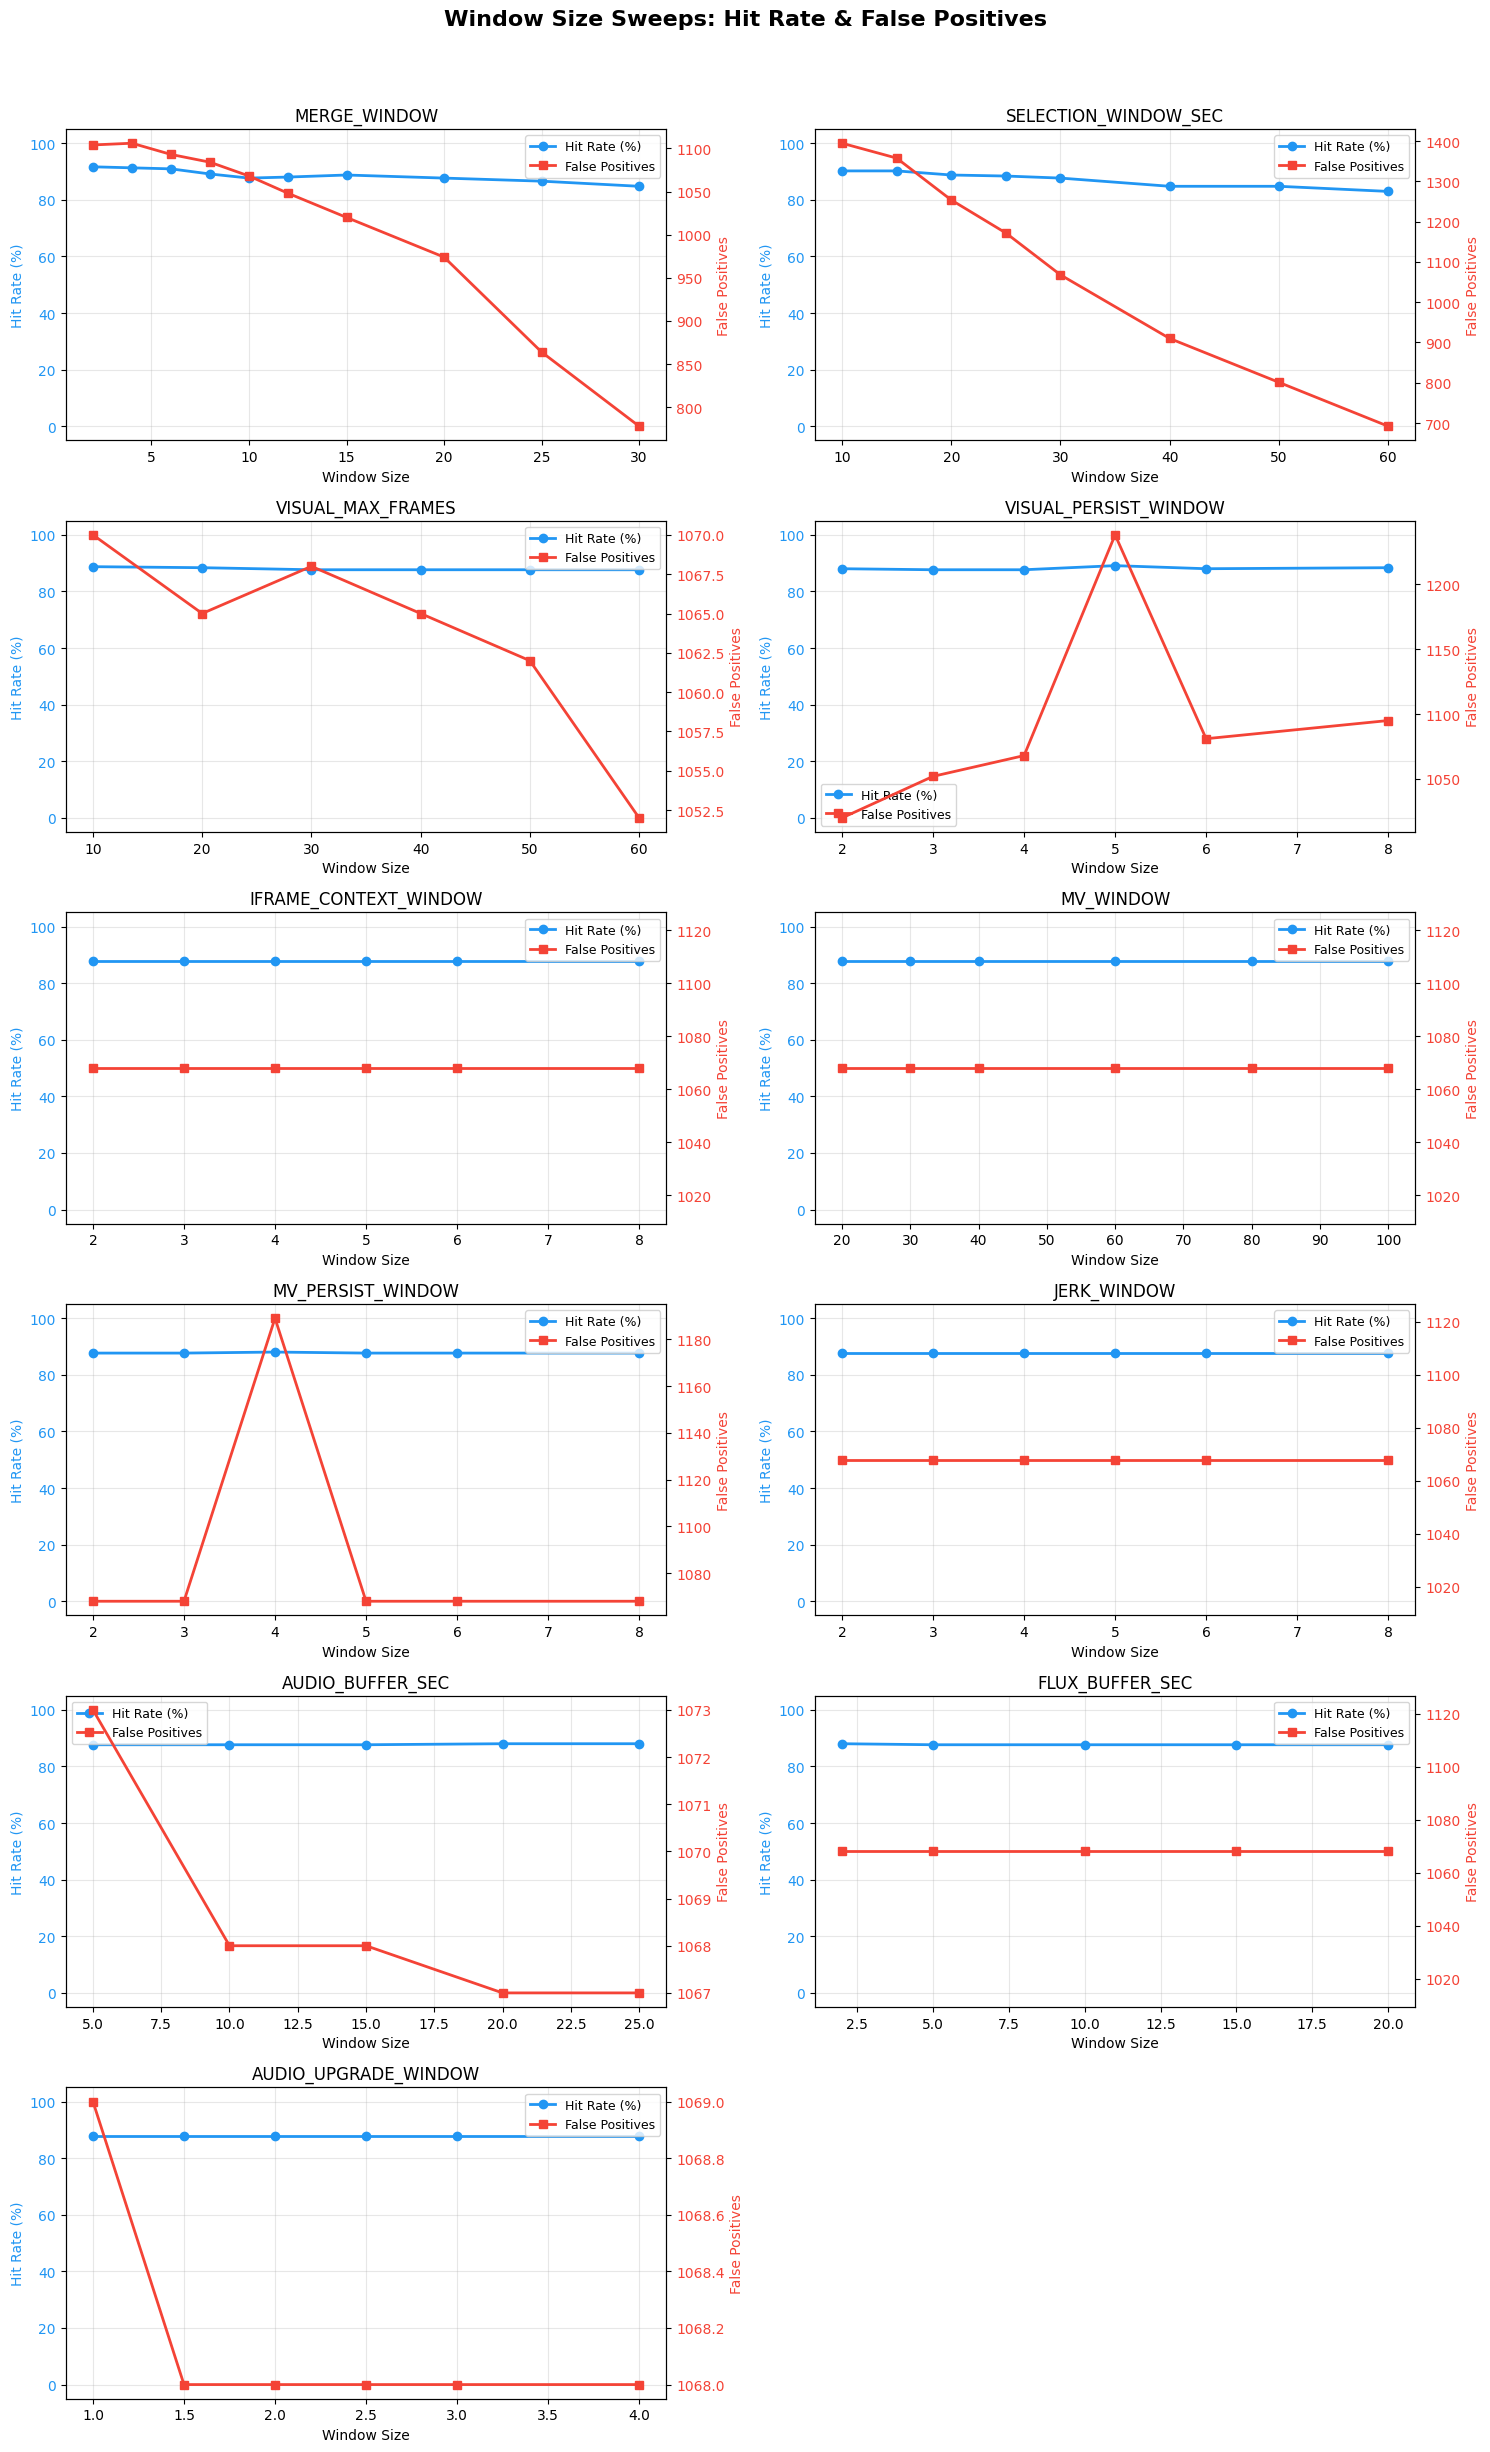

Saved combined plot → plots/all_windows_sweep.png
Saved individual window plots → plots/window_*.png


In [13]:
import math

# 1. Plot all window sweeps in a grid
num_params = len(WINDOW_SWEEPS)
cols = 2
rows = math.ceil(num_params / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
fig.suptitle('Window Size Sweeps: Hit Rate & False Positives', fontsize=16, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, (param_name, res) in enumerate(window_results.items()):
    ax = axes[i]
    ws = [r['w'] for r in res]
    hrs = [r['hit_rate'] for r in res]
    fps = [r['fp'] for r in res]
    
    ax1 = ax
    ax2 = ax.twinx()
    
    l1 = ax1.plot(ws, hrs, 'o-', color='#2196F3', lw=2, label='Hit Rate (%)')
    ax1.set_ylabel('Hit Rate (%)', color='#2196F3')
    ax1.tick_params(axis='y', labelcolor='#2196F3')
    ax1.set_ylim(-5, 105)
    
    l2 = ax2.plot(ws, fps, 's-', color='#F44336', lw=2, label='False Positives')
    ax2.set_ylabel('False Positives', color='#F44336')
    ax2.tick_params(axis='y', labelcolor='#F44336')
    
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='best', fontsize=9)
    
    ax.set_title(param_name, fontsize=12)
    ax.set_xlabel('Window Size')
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('plots/all_windows_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved combined plot → plots/all_windows_sweep.png')

# 2. Save individual plot per window size
for param_name, res in window_results.items():
    ws = [r['w'] for r in res]
    hrs = [r['hit_rate'] for r in res]
    fps = [r['fp'] for r in res]
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()
    
    l1 = ax1.plot(ws, hrs, 'o-', color='#2196F3', lw=2, label='Hit Rate (%)')
    ax1.set_ylabel('Hit Rate (%)', color='#2196F3')
    ax1.tick_params(axis='y', labelcolor='#2196F3')
    ax1.set_ylim(-5, 105)
    
    l2 = ax2.plot(ws, fps, 's-', color='#F44336', lw=2, label='False Positives')
    ax2.set_ylabel('False Positives', color='#F44336')
    ax2.tick_params(axis='y', labelcolor='#F44336')
    
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='best')
    
    ax1.set_title(f'Effect of {param_name}', fontsize=14)
    ax1.set_xlabel('Window Size')
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'plots/window_{param_name}.png', dpi=150)
    plt.close()
print('Saved individual window plots → plots/window_*.png')

In [14]:
# Pareto view removed to keep output concise.

## 2 – Best Configuration Summary

In [ ]:
print('='*60)
print('RECOMMENDED CONFIGURATION (highest hit rate, then min FP)')
print('='*60)
import numpy as npit is just logical blocks not systems
it can be workers pull from memory cache
I am just addiing additional work to decoders since it works at pixl level extracting meta data wont affect much
if 'MERGE_WINDOW' in window_results:
    best_mw = window_results['MERGE_WINDOW'][np.argmax([r['hit_rate'] for r in window_results['MERGE_WINDOW']])]['w']
    print('Best MERGE_WINDOW    :', best_mw, 's')
if 'SELECTION_WINDOW_SEC' in window_results:
    best_sw = window_results['SELECTION_WINDOW_SEC'][np.argmax([r['hit_rate'] for r in window_results['SELECTION_WINDOW_SEC']])]['w']
    print('Best SELECTION_WINDOW:', best_sw, 's')
print('Plots saved in \u2192 plots/')


RECOMMENDED CONFIGURATION (highest hit rate, then min FP)
Best MERGE_WINDOW    : 2 s
Best SELECTION_WINDOW: 10 s
Plots saved in → plots/
